# Train model

In [2]:
import pandas as pd

train_df = pd.read_csv('/kaggle/input/165-different-snakes-species/Csv/train.csv')
test_df = pd.read_csv('/kaggle/input/165-different-snakes-species/Csv/test.csv')
# Convert class_id to string in both train_df and test_df
train_df['class_id'] = train_df['class_id'].astype(str)
train_df['poisonous'] = train_df['poisonous'].astype(str)

test_df['class_id'] = test_df['class_id'].astype(str)
test_df['poisonous'] = test_df['poisonous'].astype(str)

train_df['image_path'] = "/kaggle/input/165-different-snakes-species/train/" + train_df["class_id"] + "/" + train_df["UUID"].astype(str) + ".jpg"
test_df['image_path'] = "/kaggle/input/165-different-snakes-species/test/" + test_df["class_id"] + "/" + test_df["UUID"].astype(str) + ".jpg"

print("Training DataFrame shape:", train_df.shape)
print("Test DataFrame shape:", test_df.shape)

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23816 entries, 0 to 23815
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        23816 non-null  int64  
 1   binomial          23816 non-null  object 
 2   country           23816 non-null  object 
 3   continent         23816 non-null  object 
 4   genus             23816 non-null  object 
 5   family            23816 non-null  object 
 6   UUID              23816 non-null  object 
 7   class_id          23816 non-null  object 
 8   snake_sub_family  23816 non-null  object 
 9   poisonous         23816 non-null  object 
 10  X                 23816 non-null  float64
 11  Y                 23816 non-null  float64
 12  height            23816 non-null  float64
 13  width             23816 non-null  float64
 14  image_path        23816 non-null  object 
dtypes: float64(4), int64(1), object(10)
memory usage: 2.7+ MB


In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# # Create an instance of ImageDataGenerator
# train_datagen = ImageDataGenerator(
#     validation_split=0.2  # Use 20% of data for validation
# )
target = "binomial"

train_datagen = ImageDataGenerator()

# Create training images generator
train_images = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col=target,
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=8,
    shuffle=True,
    seed=42,
    subset='training'
)

# # Create validation images generator
# val_images = train_datagen.flow_from_dataframe(
#     dataframe=train_df,
#     x_col='image_path',
#     y_col='binomial',
#     target_size=(224, 224),
#     color_mode='rgb',
#     class_mode='categorical',
#     batch_size=32,
#     shuffle=False,  # No shuffling for validation set
#     seed=42,
#     subset='validation'
# )

# Create a separate ImageDataGenerator for the test set (without validation split)
test_datagen = ImageDataGenerator()

# Create test images generator
test_images = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col=target,
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=8,
    shuffle=False  # No shuffling for test set
)

Found 23816 validated image filenames belonging to 135 classes.
Found 3138 validated image filenames belonging to 135 classes.


In [18]:
# import json

# # Assuming index_to_class is already created
# index_to_class = {v: k for k, v in train_images.class_indices.items()}

# # Define the path where you want to save the JSON file
# json_file_path = target + '.json'

# # Save the index_to_class dictionary to the JSON file
# with open(json_file_path, 'w') as json_file:
#     json.dump(index_to_class, json_file)

In [5]:
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
# from tensorflow.keras.applications import *
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# from tensorflow import keras 
# from tensorflow.keras.metrics import Precision, Recall

# # Define image size and batch size
# IMG_SIZE = (224, 224, 3)  # Target image size
# NUM_CLASSES = train_df[target].nunique()  # Number of unique classes in your dataset

# # Create the base model using MobileNetV2 (pre-trained on ImageNet)
# base_model = EfficientNetV2B3(include_top=False,weights='imagenet')
# # base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False,weights='imagenet')
# # base_model = DenseNet121(input_shape=(224, 224, 3),include_top=False,weights='imagenet')
# # base_model = ResNet50V2(input_shape=(224, 224, 3),include_top=False,weights='imagenet')

# # Define the model architecture
# model = Sequential([
#     base_model,
#     GlobalAveragePooling2D(),  # Reduce the spatial dimensions
#     Dense(NUM_CLASSES, activation='softmax')  # Output layer for multi-class classification
# ])

# # Compile the model with additional metrics
# model.compile(optimizer=Adam(learning_rate=0.001),  # Use a small learning rate
#               loss='categorical_crossentropy',      # Loss for multi-class classification
#               metrics=['accuracy', 'AUC', Precision(), Recall()])  # Track accuracy, AUC, precision, recall, F1
# # Set up callbacks
# # early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# model_checkpoint = ModelCheckpoint('best_model.keras', monitor='accuracy', save_best_only=True)

# # Train the model using the generators
# history = model.fit(
#     train_images,  # Training data generator
# #     validation_data=val_images,  # Validation data generator
#     epochs=30,  # Number of epochs to train
#     callbacks=[model_checkpoint]  # Callbacks for early stopping and model saving
# )

# # Save the training history to a file (optional)
# import pickle

# with open('training_history.pkl', 'wb') as file_pi:
#     pickle.dump(history.history, file_pi)

52606240/52606240 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/30


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1728829054.322310      97 service.cc:145] XLA service 0x78a6380026c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1728829054.322393      97 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1728829155.324532      97 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion', 36 bytes spill stores, 36 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_2', 36 bytes spill stores, 36 bytes spill loads
ptxa

2977/2977 ━━━━━━━━━━━━━━━━━━━━ 396s 79ms/step - AUC: 0.8039 - accuracy: 0.1818 - loss: 3.5181 - precision: 0.4626 - recall: 0.0373
Epoch 2/30
2977/2977 ━━━━━━━━━━━━━━━━━━━━ 202s 68ms/step - AUC: 0.9181 - accuracy: 0.3434 - loss: 2.5267 - precision: 0.6608 - recall: 0.1539
Epoch 3/30
2977/2977 ━━━━━━━━━━━━━━━━━━━━ 201s 67ms/step - AUC: 0.9425 - accuracy: 0.4443 - loss: 2.0966 - precision: 0.7119 - recall: 0.2581
Epoch 4/30
2977/2977 ━━━━━━━━━━━━━━━━━━━━ 201s 67ms/step - AUC: 0.9589 - accuracy: 0.5177 - loss: 1.7685 - precision: 0.7513 - recall: 0.3503
Epoch 5/30
2977/2977 ━━━━━━━━━━━━━━━━━━━━ 198s 66ms/step - AUC: 0.9701 - accuracy: 0.5869 - loss: 1.4859 - precision: 0.7884 - recall: 0.4400
Epoch 6/30
2977/2977 ━━━━━━━━━━━━━━━━━━━━ 199s 67ms/step - AUC: 0.9777 - accuracy: 0.6377 - loss: 1.2735 - precision: 0.8059 - recall: 0.5074
Epoch 7/30
2977/2977 ━━━━━━━━━━━━━━━━━━━━ 200s 67ms/step - AUC: 0.9843 - accuracy: 0.6999 - loss: 1.0309 - precision: 0.8401 - recall: 0.5939
Epoch 8/30
2977/2

In [6]:
# from sklearn.metrics import classification_report
# import numpy as np

# pred = model.predict(test_images)
# pred = np.argmax(pred,axis=1)
# # Get the class-to-index mapping from the training data generator
# label_mapping = train_images.class_indices
# index_to_class = {v: k for k, v in label_mapping.items()}

# predicted_labels = [index_to_class[idx] for idx in pred]
# y_test = list(test_df[target].astype(str))
# print(classification_report(y_test, predicted_labels))

/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


393/393 ━━━━━━━━━━━━━━━━━━━━ 47s 102ms/step
                precision    recall  f1-score   support

   Agkistrodon       0.23      0.29      0.25        42
     Ahaetulla       0.52      0.57      0.54        54
       Arizona       0.26      0.41      0.32        22
     Aspidites       0.50      0.76      0.60        21
      Atractus       0.47      0.52      0.49        27
    Austrelaps       0.40      0.18      0.25        22
         Bitis       0.50      0.47      0.48        51
           Boa       0.07      0.23      0.11        13
   Bogertophis       0.46      0.62      0.52        26
         Boiga       0.40      0.50      0.45        46
   Bothriechis       0.70      0.67      0.68        24
      Bothrops       0.46      0.36      0.40        53
      Bungarus       0.76      0.73      0.75        30
    Carphophis       0.47      0.53      0.50        51
        Causus       0.34      0.40      0.37        25
     Cemophora       0.70      0.62      0.65        26
   

In [7]:
# result = model.evaluate(test_images)
# print(result)

  5/393 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - AUC: 0.8266 - accuracy: 0.4392 - loss: 3.6306 - precision: 0.4645 - recall: 0.3821

I0000 00:00:1728835249.031598      98 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_44', 8 bytes spill stores, 8 bytes spill loads



393/393 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - AUC: 0.8715 - accuracy: 0.4902 - loss: 3.0452 - precision: 0.5424 - recall: 0.4646
[3.1957569122314453, 0.48757171630859375, 0.864687442779541, 0.5380635857582092, 0.463989794254303]


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Get a batch of test images and true labels
test_images_batch, true_labels_batch = next(test_images)

# Step 2: Make predictions on the batch
predictions = model.predict(test_images_batch)
predicted_classes = np.argmax(predictions, axis=1)  # Convert one-hot vectors to class indices

# Step 3: Get the mapping from index to class
index_to_class = {v: k for k, v in train_images.class_indices.items()}

# Step 4: Map predicted and true labels to class names
predicted_labels = [index_to_class[idx] for idx in predicted_classes]
true_labels = [index_to_class[np.argmax(label)] for label in true_labels_batch]

# Step 5: Plot some images with predicted and true labels
plt.figure(figsize=(12, 12))
for i in range(9):  # Show 9 images
    plt.subplot(3, 3, i + 1)
    plt.imshow(test_images_batch[i].astype("uint8"))  # Plot the image
    plt.title(f"True: {true_labels[i]}\nPredicted: {predicted_labels[i]}")
    plt.axis('off')  # Hide axis

plt.tight_layout()
plt.show()

# Performance

## Plot training history of 4 models (30 epochs)

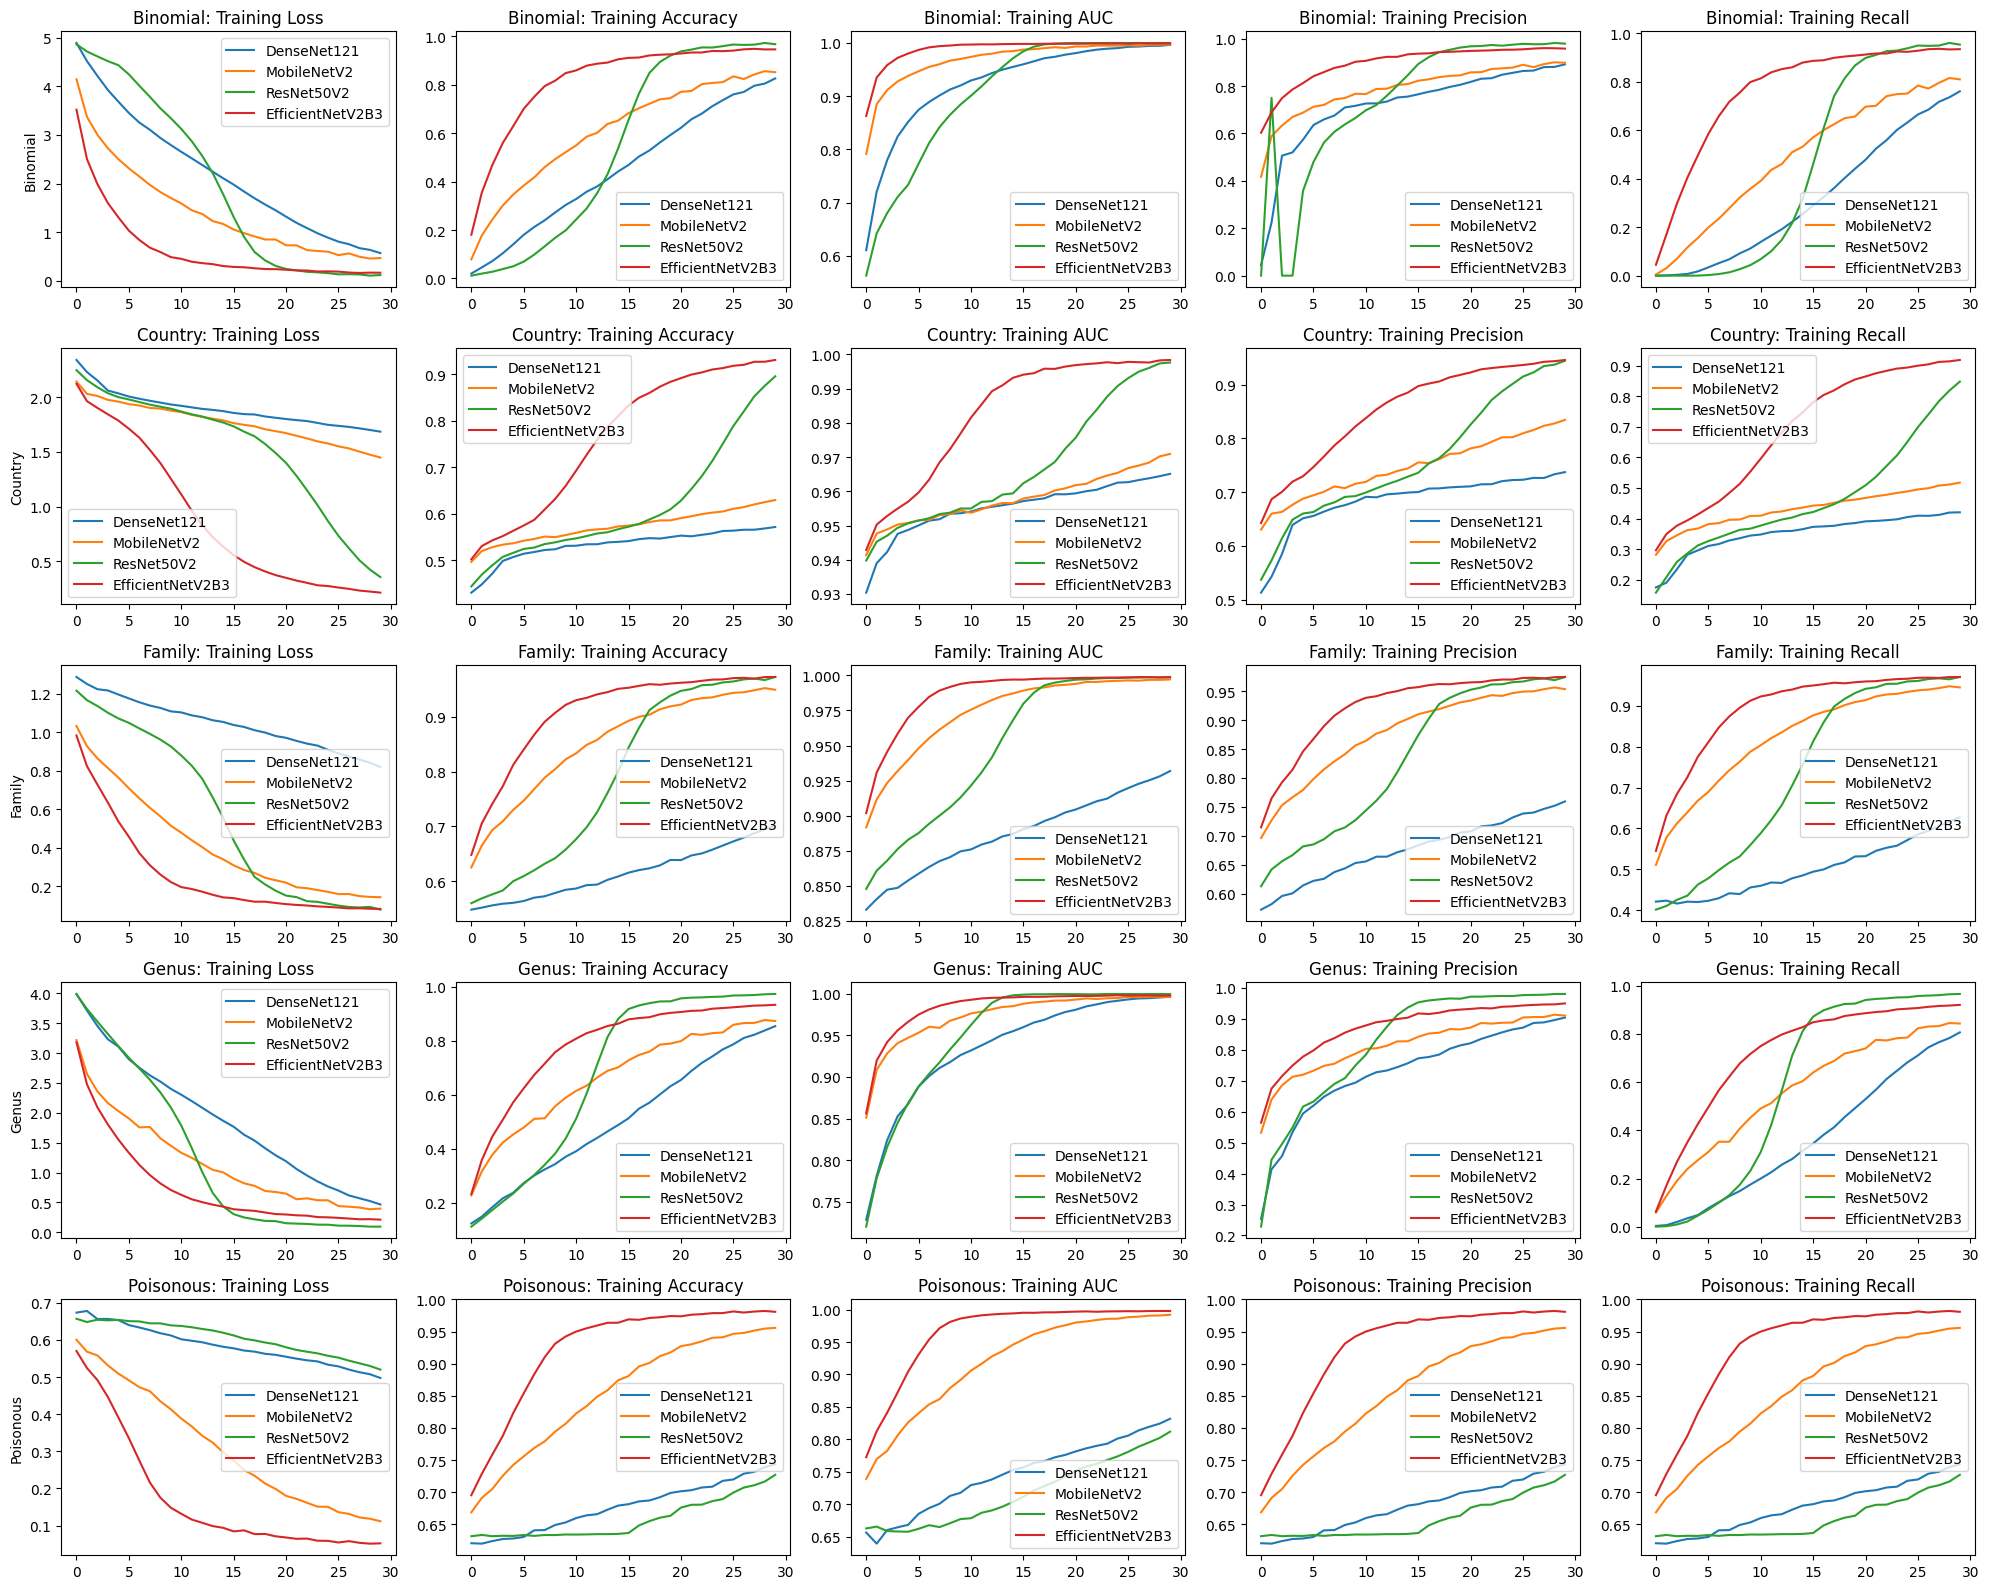

In [1]:
import pickle
import os  # To check if the file exists
import matplotlib.pyplot as plt

# Step 1: Define task names and model names
tasks = ['Binomial', 'Country', 'Family', 'Genus', 'Poisonous']
model_names = ['DenseNet121', 'MobileNetV2', 'ResNet50V2', 'EfficientNetV2B3']

# Step 2: Define the base path for the history files
base_path = '/kaggle/input/snakeclassificationmodel'

# Step 3: Prepare a subplot with 6 rows and 5 columns (6 tasks, 5 metrics per task)
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(20, 16))  # 6 rows, 5 cols

# Step 5: Loop over each task and plot the corresponding metrics
for row_idx, task in enumerate(tasks):
    histories = []  # Clear the history list for each task

    # Dynamically load the training histories for each model
    for model in model_names:
        file_path = f'{base_path}/{task}/{task}/{model}_training_history.pkl'
        with open(file_path, 'rb') as f:
            histories.append(pickle.load(f))  # Append each history dictionary to the list

    # Extract the metrics from each history
    train_acc = [h['accuracy'] for h in histories]
    train_loss = [h['loss'] for h in histories]
    train_auc = [h['AUC'] for h in histories]
    train_precision = [h['precision'] if 'precision' in h else h['precision_1'] for h in histories]
    train_recall = [h['recall'] if 'recall' in h else h['recall_1'] for h in histories]

    # Plot for the current task
    axes[row_idx, 0].set_title(f'{task}: Training Loss')
    for i in range(4):
        axes[row_idx, 0].plot(train_loss[i], label=f'{model_names[i]}')
    axes[row_idx, 0].set_ylabel(task)
    axes[row_idx, 0].legend()

    axes[row_idx, 1].set_title(f'{task}: Training Accuracy')
    for i in range(4):
        axes[row_idx, 1].plot(train_acc[i], label=f'{model_names[i]}')
    axes[row_idx, 1].legend()

    axes[row_idx, 2].set_title(f'{task}: Training AUC')
    for i in range(4):
        axes[row_idx, 2].plot(train_auc[i], label=f'{model_names[i]}')
    axes[row_idx, 2].legend()

    axes[row_idx, 3].set_title(f'{task}: Training Precision')
    for i in range(4):
        axes[row_idx, 3].plot(train_precision[i], label=f'{model_names[i]}')
    axes[row_idx, 3].legend()

    axes[row_idx, 4].set_title(f'{task}: Training Recall')
    for i in range(4):
        axes[row_idx, 4].plot(train_recall[i], label=f'{model_names[i]}')
    axes[row_idx, 4].legend()

# Step 6: Adjust the layout and display the plots
plt.tight_layout()
plt.show()


## Compare performance of 4 models

Creating test generator for task: Binomial
Found 3138 validated image filenames belonging to 135 classes.
Creating test generator for task: Country
Found 3138 validated image filenames belonging to 76 classes.
Found 23816 validated image filenames belonging to 114 classes.
Creating test generator for task: Family
Found 3138 validated image filenames belonging to 6 classes.
Creating test generator for task: Genus
Found 3138 validated image filenames belonging to 80 classes.
Creating test generator for task: Poisonous
Found 3138 validated image filenames belonging to 2 classes.

Evaluating models for task: Binomial
Loading model DenseNet121 for task: Binomial
Evaluating DenseNet121 for task: Binomial...


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1728993418.064052      75 service.cc:145] XLA service 0x7c3bf0003960 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1728993418.064119      75 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


  3/393 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - AUC: 0.7626 - accuracy: 0.2083 - loss: 4.7390 - precision: 0.3226 - recall: 0.1736   

I0000 00:00:1728993427.410506      75 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


393/393 ━━━━━━━━━━━━━━━━━━━━ 50s 86ms/step - AUC: 0.7878 - accuracy: 0.2811 - loss: 4.6753 - precision: 0.3651 - recall: 0.2503
Loading model MobileNetV2 for task: Binomial
Evaluating MobileNetV2 for task: Binomial...
393/393 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - AUC: 0.8116 - accuracy: 0.3028 - loss: 4.4640 - precision_1: 0.3687 - recall_1: 0.2765
Loading model ResNet50V2 for task: Binomial
Evaluating ResNet50V2 for task: Binomial...
393/393 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - AUC: 0.6785 - accuracy: 0.1411 - loss: 7.2763 - precision: 0.1802 - recall: 0.1202
Loading model EfficientNetV2B3 for task: Binomial
Evaluating EfficientNetV2B3 for task: Binomial...
393/393 ━━━━━━━━━━━━━━━━━━━━ 29s 43ms/step - AUC: 0.8652 - accuracy: 0.4797 - loss: 3.2414 - precision: 0.5420 - recall: 0.4590

Evaluating models for task: Country
Loading model DenseNet121 for task: Country
Evaluating EfficientNetV2B3 for task: Country...
393/393 ━━━━━━━━━━━━━━━━━━━━ 27s 41ms/step - AUC: 0.5063 - accuracy: 0.0114 

...

I0000 00:00:1728993934.667356      75 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_10', 8 bytes spill stores, 8 bytes spill loads



393/393 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - AUC: 0.7381 - accuracy: 0.2503 - loss: 5.5301 - precision: 0.3026 - recall: 0.2306
Loading model EfficientNetV2B3 for task: Genus
Evaluating EfficientNetV2B3 for task: Genus...
  5/393 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - AUC: 0.8266 - accuracy: 0.4392 - loss: 3.6306 - precision: 0.4645 - recall: 0.3821  

I0000 00:00:1728993979.528885      76 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_44', 8 bytes spill stores, 8 bytes spill loads



393/393 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - AUC: 0.8715 - accuracy: 0.4902 - loss: 3.0452 - precision: 0.5424 - recall: 0.4646

Evaluating models for task: Poisonous
Loading model DenseNet121 for task: Poisonous
Evaluating DenseNet121 for task: Poisonous...
393/393 ━━━━━━━━━━━━━━━━━━━━ 30s 45ms/step - AUC: 0.7422 - accuracy: 0.6625 - loss: 0.5893 - precision: 0.6625 - recall: 0.6625
Loading model MobileNetV2 for task: Poisonous
Evaluating MobileNetV2 for task: Poisonous...
393/393 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - AUC: 0.7601 - accuracy: 0.6950 - loss: 1.4775 - precision: 0.6950 - recall: 0.6950
Loading model ResNet50V2 for task: Poisonous
Evaluating ResNet50V2 for task: Poisonous...
393/393 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - AUC: 0.7181 - accuracy: 0.6394 - loss: 0.6196 - precision: 0.6394 - recall: 0.6394
Loading model EfficientNetV2B3 for task: Poisonous
Evaluating EfficientNetV2B3 for task: Poisonous...
393/393 ━━━━━━━━━━━━━━━━━━━━ 27s 41ms/step - AUC: 0.7878 - accuracy: 0.71

/tmp/ipykernel_30/166232005.py:114: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[task_idx, metric_idx].set_xticklabels(model_names, rotation=45, ha='right')


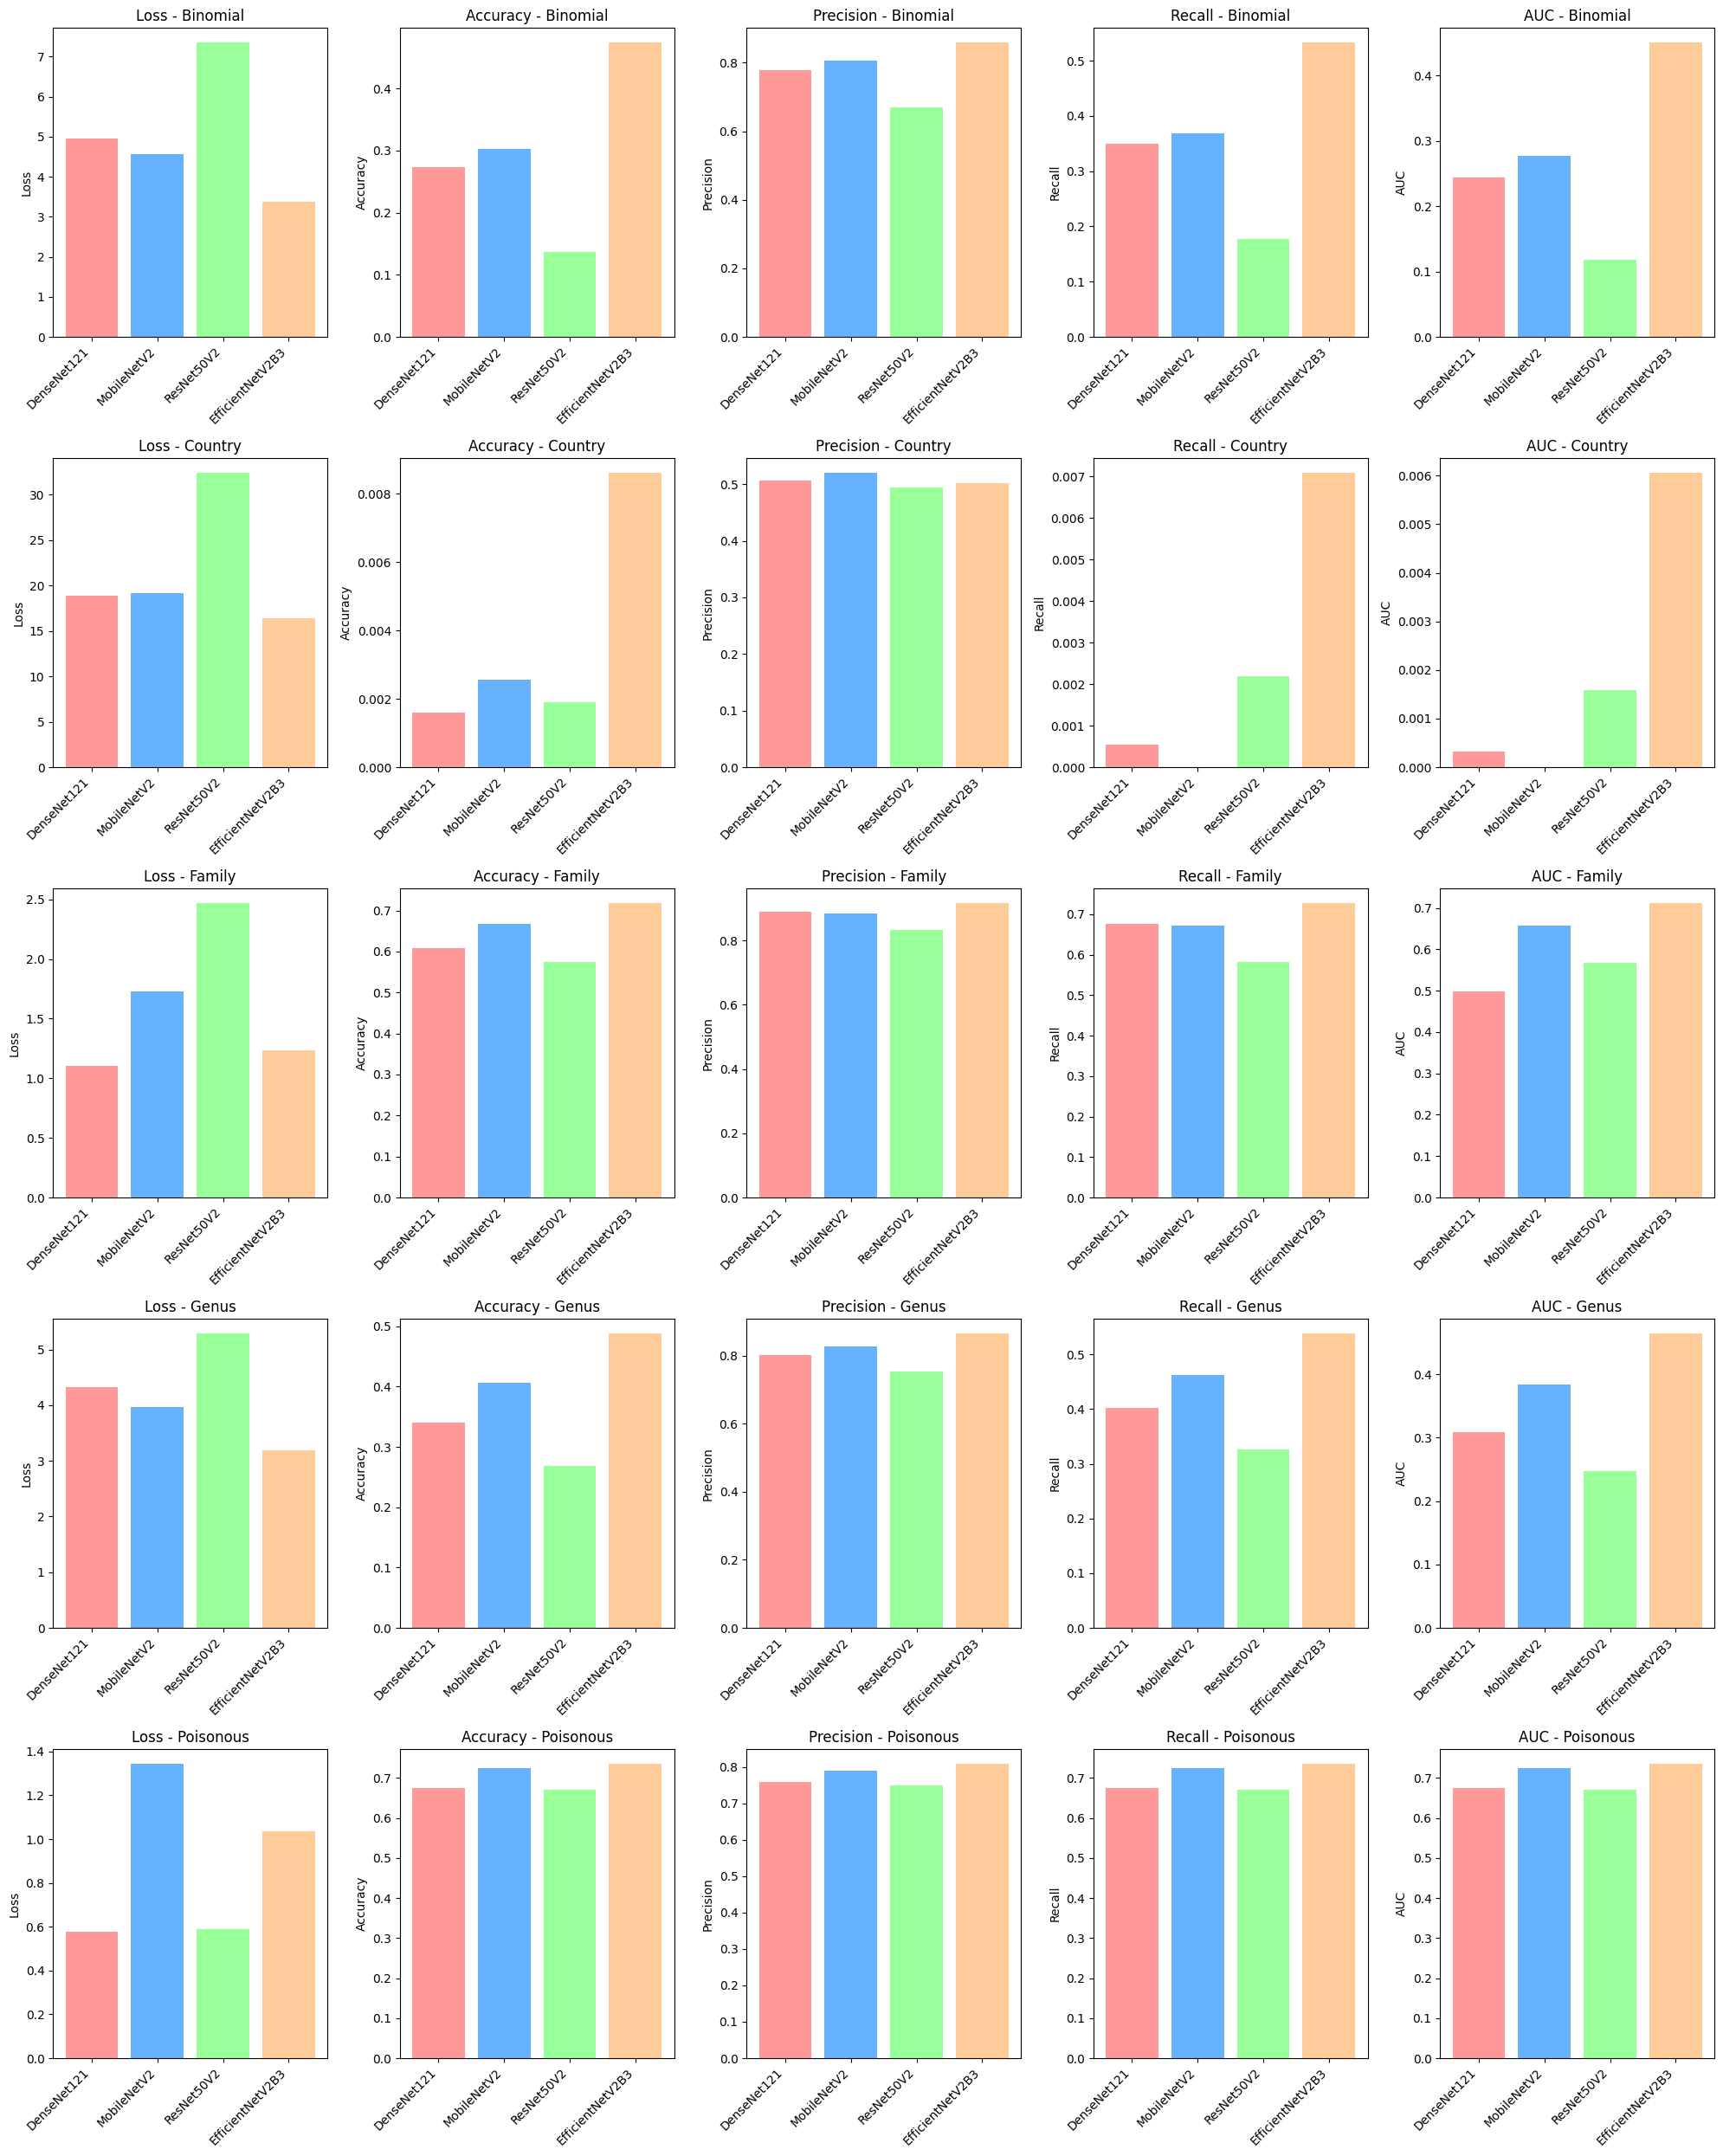

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd

# Step 1: Define task names and model names
tasks = ['Binomial', 'Country', 'Family', 'Genus', 'Poisonous']
model_names = ['DenseNet121', 'MobileNetV2', 'ResNet50V2', 'EfficientNetV2B3']

train_df = pd.read_csv('/kaggle/input/165-different-snakes-species/Csv/train.csv')
test_df = pd.read_csv('/kaggle/input/165-different-snakes-species/Csv/test.csv')
# Convert class_id to string in both train_df and test_df
train_df['class_id'] = train_df['class_id'].astype(str)
train_df['poisonous'] = train_df['poisonous'].astype(str)

test_df['class_id'] = test_df['class_id'].astype(str)
test_df['poisonous'] = test_df['poisonous'].astype(str)

train_df['image_path'] = "/kaggle/input/165-different-snakes-species/train/" + train_df["class_id"] + "/" + train_df["UUID"].astype(str) + ".jpg"
test_df['image_path'] = "/kaggle/input/165-different-snakes-species/test/" + test_df["class_id"] + "/" + test_df["UUID"].astype(str) + ".jpg"

# Step 2: Create an ImageDataGenerator for test images
test_datagen = ImageDataGenerator()

# Dictionary to store test image generators for each task
test_generators = {}

# Step 3: Iterate over each task and create test image generators
for task in tasks:
    print(f"Creating test generator for task: {task}")
    # Create test image generator for the current task
    test_generators[task] = test_datagen.flow_from_dataframe(
        dataframe=test_df,
        x_col='image_path',   # Path to images
        y_col=task.lower(),  # Dynamically selected target column
        target_size=(224, 224),
        color_mode='rgb',
        class_mode='categorical',
        batch_size=8,
        shuffle=False
    )
    
    if task == 'Country':
        train_datagen = ImageDataGenerator()
        train_images = train_datagen.flow_from_dataframe(
            dataframe=train_df,
            x_col='image_path',   # Path to images
            y_col=task.lower(),  # Dynamically selected target column
            target_size=(224, 224),
            color_mode='rgb',
            class_mode='categorical',
            batch_size=8,
            shuffle=False
        )
        test_generators[task].class_indices = train_images.class_indices

# Dictionary to store evaluation results for each task
task_results = {}

# Step 4: Iterate over each task for evaluation
for task in tasks:
    print(f"\nEvaluating models for task: {task}")
    
    # Store results for this task
    results = {}

    # Iterate over each model for the current task
    for model_name in model_names:
        # Load the model from the appropriate path
        model_path = f'/kaggle/input/snakeclassificationmodel/{task}/{task}/{model_name}.keras'
        print(f"Loading model {model_name} for task: {task}")
        model = load_model(model_path)

        # Evaluate the model on the test set for the current task
        print(f"Evaluating {model_name} for task: {task}...")
        evaluation = model.evaluate(test_generators[task], verbose=1)

        # Assuming evaluation returns [loss, accuracy, precision, recall, AUC]
        results[model_name] = evaluation

    # Convert results to a dictionary format for easier plotting
    metrics = ['Loss', 'Accuracy', 'Precision', 'Recall', 'AUC']
    metrics_results = {metric: [] for metric in metrics}

    for model_name in model_names:
        metrics_results['Loss'].append(results[model_name][0])
        metrics_results['Accuracy'].append(results[model_name][1])
        metrics_results['Precision'].append(results[model_name][2])
        metrics_results['Recall'].append(results[model_name][3])
        metrics_results['AUC'].append(results[model_name][4])

    # Save the results for this task
    task_results[task] = metrics_results

# Step 5: Plot the metrics for all models for each task
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(20, 25))  # 5 rows for tasks, 5 columns for metrics

# Metrics to be plotted
metrics = ['Loss', 'Accuracy', 'Precision', 'Recall', 'AUC']

# Iterate over tasks and plot metrics for each task
for task_idx, task in enumerate(tasks):
    # Get metrics results for the current task
    metrics_results = task_results[task]
    
    # Plot for each metric in the corresponding column
    for metric_idx, metric in enumerate(metrics):
        # Bar plot for the current metric and task
        axes[task_idx, metric_idx].bar(model_names, metrics_results[metric], 
                                       color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99'])
        axes[task_idx, metric_idx].set_title(f'{metric} - {task}')
        axes[task_idx, metric_idx].set_ylabel(metric)
        axes[task_idx, metric_idx].set_xticklabels(model_names, rotation=45, ha='right')

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()

Found 3138 validated image filenames belonging to 135 classes.
Found 3138 validated image filenames belonging to 76 classes.
Found 3138 validated image filenames belonging to 6 classes.
Found 3138 validated image filenames belonging to 80 classes.
Found 3138 validated image filenames belonging to 2 classes.


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


393/393 ━━━━━━━━━━━━━━━━━━━━ 29s 55ms/step
393/393 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step
393/393 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step
393/393 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


393/393 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step
393/393 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step
393/393 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step
393/393 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step


...

393/393 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step
393/393 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step
393/393 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step
393/393 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


393/393 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step
393/393 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step
393/393 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step
393/393 ━━━━━━━━━━━━━━━━━━━━ 25s 47ms/step


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


393/393 ━━━━━━━━━━━━━━━━━━━━ 27s 50ms/step
393/393 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step
393/393 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step
393/393 ━━━━━━━━━━━━━━━━━━━━ 25s 46ms/step


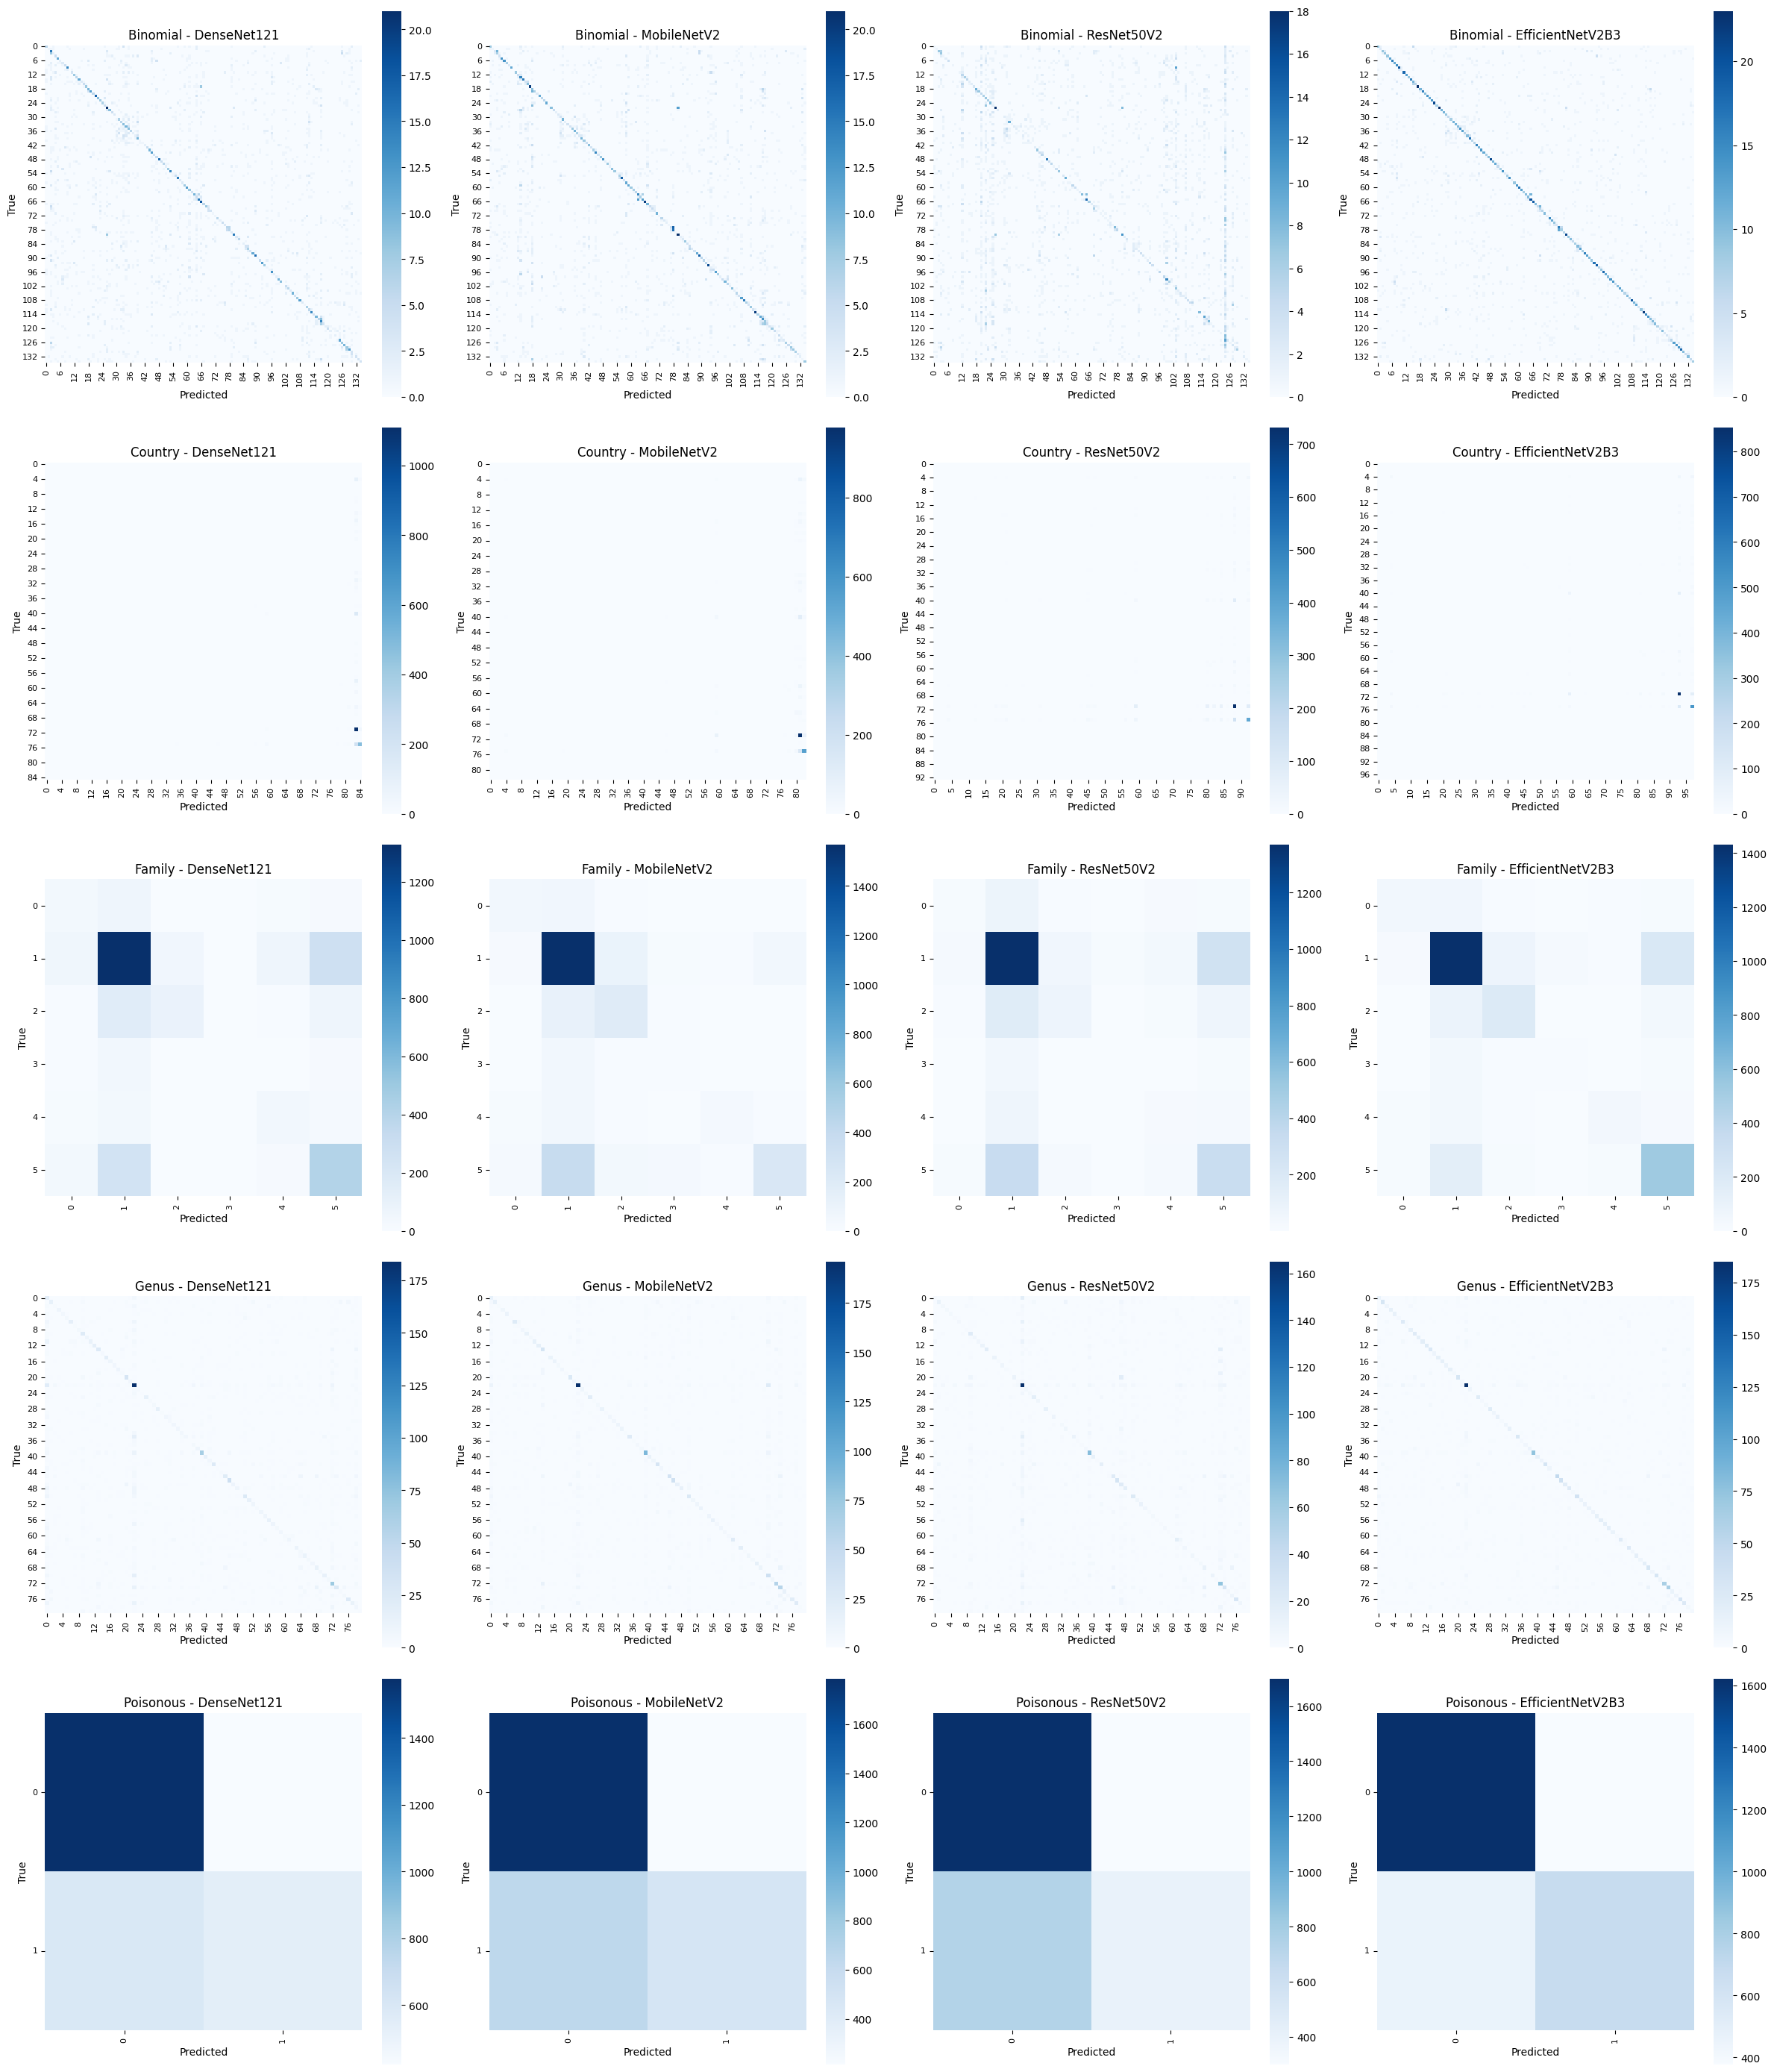

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Load datasets and set up as before
tasks = ['Binomial', 'Country', 'Family', 'Genus', 'Poisonous']
model_names = ['DenseNet121', 'MobileNetV2', 'ResNet50V2', 'EfficientNetV2B3']

train_df = pd.read_csv('/kaggle/input/165-different-snakes-species/Csv/train.csv')
test_df = pd.read_csv('/kaggle/input/165-different-snakes-species/Csv/test.csv')
train_df['class_id'] = train_df['class_id'].astype(str)
train_df['poisonous'] = train_df['poisonous'].astype(str)

test_df['class_id'] = test_df['class_id'].astype(str)
test_df['poisonous'] = test_df['poisonous'].astype(str)

train_df['image_path'] = "/kaggle/input/165-different-snakes-species/train/" + train_df["class_id"] + "/" + train_df["UUID"].astype(str) + ".jpg"
test_df['image_path'] = "/kaggle/input/165-different-snakes-species/test/" + test_df["class_id"] + "/" + test_df["UUID"].astype(str) + ".jpg"

# Image data generator for test images
test_datagen = ImageDataGenerator()
test_generators = {}
true_labels_dict = {}

# Create test generators and store true labels for each task
for task in tasks:
    test_generators[task] = test_datagen.flow_from_dataframe(
        dataframe=test_df,
        x_col='image_path',
        y_col=task.lower(),
        target_size=(224, 224),
        color_mode='rgb',
        class_mode='categorical',
        batch_size=8,
        shuffle=False
    )
    true_labels_dict[task] = test_generators[task].classes

# Dictionary to store confusion matrices for each task and model
confusion_matrices = {}

# Generate confusion matrices
for task in tasks:
    confusion_matrices[task] = {}
    for model_name in model_names:
        # Load the model
        model_path = f'/kaggle/input/snakeclassificationmodel/{task}/{task}/{model_name}.keras'
        model = load_model(model_path)
        
        # Get predictions
        predictions = model.predict(test_generators[task])
        predicted_labels = np.argmax(predictions, axis=1)

        # Compute confusion matrix
        cm = confusion_matrix(true_labels_dict[task], predicted_labels)
        confusion_matrices[task][model_name] = cm

# Plotting confusion matrices with a larger figure size for better readability
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(24, 28))  # Bigger size for readability

for task_idx, task in enumerate(tasks):
    for model_idx, model_name in enumerate(model_names):
        cm = confusion_matrices[task][model_name]
        sns.heatmap(
            cm,
            annot=False,            # Set to False for less clutter
            fmt="d",
            cmap="Blues",
            cbar=True,
            ax=axes[task_idx, model_idx],
            square=True
        )
        axes[task_idx, model_idx].set_title(f'{task} - {model_name}', fontsize=12)
        axes[task_idx, model_idx].set_xlabel('Predicted', fontsize=10)
        axes[task_idx, model_idx].set_ylabel('True', fontsize=10)
        axes[task_idx, model_idx].tick_params(axis='x', rotation=90, labelsize=8)
        axes[task_idx, model_idx].tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.show()


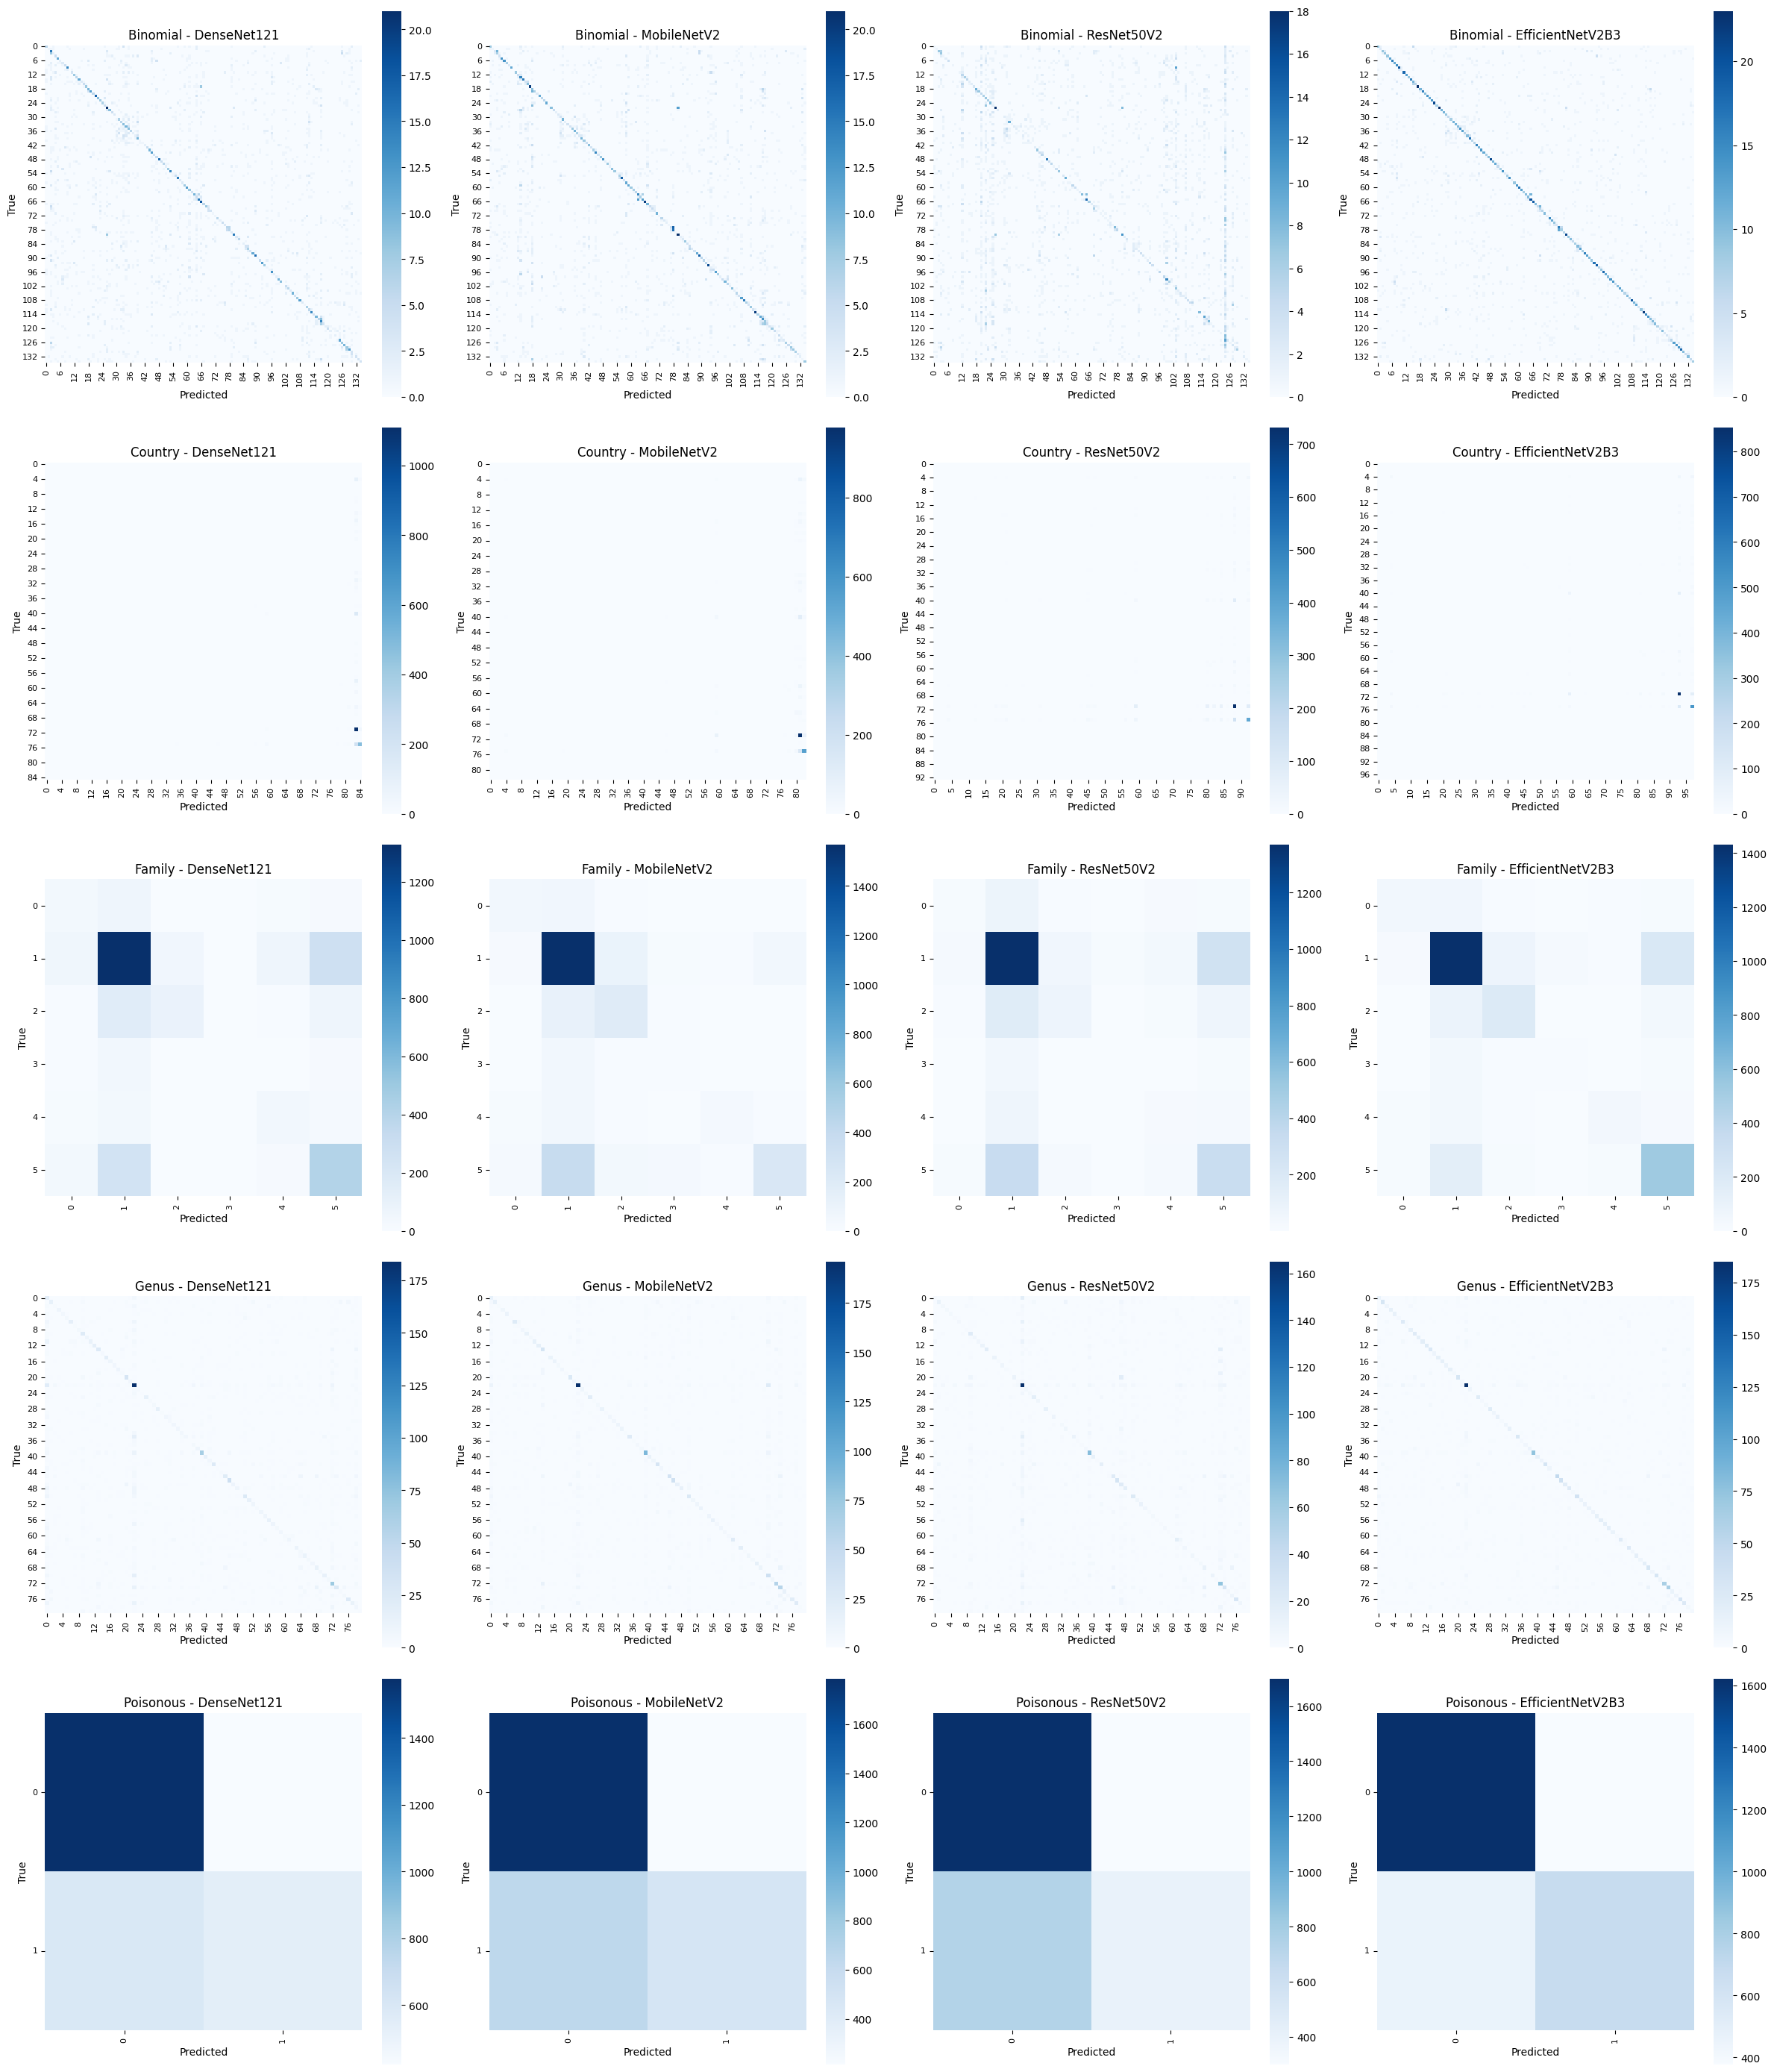## End to End prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Predictions for image: /kaggle/input/165-different-snakes-species/train/113/05a5e4e1cbd642b2939e822ce5308587.jpg

Binomial: Crotalus atrox 22.26%
Country: Trinidad and Tobago (North America) 38.63%
Family: Viperidae 56.94%
Genus: Leptodeira 61.43%
Poisonous: 1 74.22%


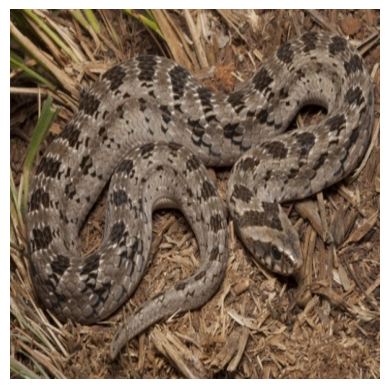

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import json
import matplotlib.pyplot as plt

# Continent mapping for countries
country_to_continent = {
    "Albania": "Europe", "Algeria": "Africa", "Angola": "Africa", "Argentina": "South America",
    "Australia": "Australia", "Bangladesh": "Asia", "Belize": "North America", "Benin": "Africa",
    "Bhutan": "Asia", "Bolivia": "South America", "Bosnia and Herzegovina": "Europe", 
    "Botswana": "Africa", "Brazil": "South America", "Brunei": "Asia", "Bulgaria": "Europe", 
    "Burma": "Asia", "Burundi": "Africa", "Cambodia": "Asia", "Canada": "North America", 
    "China": "Asia", "Colombia": "South America", "Costa Rica": "North America", "Croatia": "Europe", 
    "Democratic Republic of the Congo": "Africa", "Denmark": "Europe", "East Timor": "Asia", 
    "Ecuador": "South America", "El Salvador": "North America", "Ethiopia": "Africa", "Fiji": "Australia",
    "Finland": "Europe", "France": "Europe", "French Guiana": "South America", "Gabon": "Africa", 
    "Gambia": "Africa", "Germany": "Europe", "Ghana": "Africa", "Greece": "Europe", "Guam": "Oceania", 
    "Guatemala": "North America", "Guyana": "South America", "Honduras": "North America", "Hong Kong": "Asia", 
    "Hungary": "Europe", "India": "Asia", "Indonesia": "Asia", "Italy": "Europe", "Ivory Coast": "Africa", 
    "Japan": "Asia", "Kazakhstan": "Asia", "Kenya": "Africa", "Kyrgyzstan": "Asia", "Laos": "Asia", 
    "Macau S.A.R": "Asia", "Malawi": "Africa", "Malaysia": "Asia", "Mali": "Africa", "Mauritius": "Africa", 
    "Mexico": "North America", "Mongolia": "Asia", "Montenegro": "Europe", "Morocco": "Africa", 
    "Mozambique": "Africa", "Namibia": "Africa", "Netherlands": "Europe", "Nicaragua": "North America", 
    "Nigeria": "Africa", "Norway": "Europe", "Oman": "Asia", "Pakistan": "Asia", "Palau": "Oceania", 
    "Panama": "North America", "Papua New Guinea": "Australia", "Paraguay": "South America", 
    "Peru": "South America", "Philippines": "Asia", "Portugal": "Europe", "Puerto Rico": "North America", 
    "Republic of Serbia": "Europe", "Romania": "Europe", "Russia": "Europe/Asia", "Rwanda": "Africa", 
    "Saudi Arabia": "Asia", "Senegal": "Africa", "Singapore": "Asia", "Slovenia": "Europe", 
    "South Africa": "Africa", "South Korea": "Asia", "South Sudan": "Africa", "Spain": "Europe", 
    "Sri Lanka": "Asia", "Sudan": "Africa", "Suriname": "South America", "Swaziland": "Africa", 
    "Sweden": "Europe", "Switzerland": "Europe", "Taiwan": "Asia", "Tanzania": "Africa", "Thailand": "Asia", 
    "Tonga": "Oceania", "Trinidad and Tobago": "North America", "Tunisia": "Africa", "Turkey": "Europe/Asia", 
    "Uganda": "Africa", "Ukraine": "Europe", "United Kingdom": "Europe", "United States of America": "North America", 
    "Vanuatu": "Oceania", "Venezuela": "South America", "Vietnam": "Asia", "Zambia": "Africa", "Zimbabwe": "Africa", 
    "unknown": "Unknown"
}

tasks = ['Binomial', 'Country', 'Family', 'Genus', 'Poisonous']

model_paths = []
for task in tasks:
    model_paths.append(f'/kaggle/input/snakeclassificationmodel/{task}/{task}/EfficientNetV2B3.keras')

models = [tf.keras.models.load_model(model_path) for model_path in model_paths]

# Step 2: Load class dictionaries for each task (separate JSON files for each task)
class_dict_paths = [
    '/kaggle/input/snakeclassificationmodel/binomial.json',  # Class dict for Task 1
    '/kaggle/input/snakeclassificationmodel/country.json',   # Class dict for Task 2
    '/kaggle/input/snakeclassificationmodel/family.json',    # Class dict for Task 3
    '/kaggle/input/snakeclassificationmodel/genus.json',     # Class dict for Task 4
    '/kaggle/input/snakeclassificationmodel/poisonous.json'  # Class dict for Task 5
]
class_dicts = []
for class_dict_path in class_dict_paths:
    with open(class_dict_path, 'r') as json_file:
        class_dicts.append(json.load(json_file))

# Step 3: Preprocess the input image (resize and normalize)
def preprocess_image(image_path, target_size=(224, 224)):
    img = image.load_img(image_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array / 255.0  # Normalize image data
    return img_array

# Example image path to test
image_path = '/kaggle/input/165-different-snakes-species/train/113/05a5e4e1cbd642b2939e822ce5308587.jpg'
preprocessed_image = preprocess_image(image_path)

# Step 4: Make predictions using each model
predictions = []
for model in models:
    pred = model.predict(preprocessed_image)
    predictions.append(pred)

# Step 5: Map predictions to respective class labels and show confidence
def get_class_label_with_confidence(pred, class_dict):
    class_index = np.argmax(pred)  # Get the predicted class index
    confidence = np.max(pred)      # Get the confidence of the prediction (max probability)
    class_name = class_dict[str(class_index)]  # Get class name from the dictionary
    return class_name, confidence

# Step 6: Display the predictions from all models with confidence, including continent for Country task
print(f"Predictions for image: {image_path}\n")
for i, pred in enumerate(predictions):
    predicted_class, confidence = get_class_label_with_confidence(pred, class_dicts[i])
    
    if tasks[i] == 'Country':
        continent = country_to_continent.get(predicted_class, "Unknown")  # Get continent for the predicted country
        print(f"{tasks[i]}: {predicted_class} ({continent}) {confidence*100:.2f}%")
    else:
        print(f"{tasks[i]}: {predicted_class} {confidence*100:.2f}%")

# Optionally, display the image
img = image.load_img(image_path)
plt.imshow(img)
plt.axis('off')
plt.show()

In [6]:
import pandas as pd
test_df = pd.read_csv('/kaggle/input/165-different-snakes-species/Csv/test.csv')
print(test_df[test_df['UUID'] == "2abdbcff11324033a515bf40db35eba9"])

    Unnamed: 0                binomial                   country  \
36          36  Agkistrodon piscivorus  United States of America   

        continent        genus     family                              UUID  \
36  North America  Agkistrodon  Viperidae  2abdbcff11324033a515bf40db35eba9   

    class_id        snake_sub_family  poisonous  
36        20  Agkistrodon piscivorus          1  


In [8]:
import pandas as pd
train_df = pd.read_csv('/kaggle/input/165-different-snakes-species/Csv/train.csv')
print(train_df[train_df['UUID'] == "05a5e4e1cbd642b2939e822ce5308587"])

      Unnamed: 0           binomial       country continent   genus  \
3884        3884  Causus rhombeatus  South Africa    Africa  Causus   

         family                              UUID  class_id  \
3884  Viperidae  05a5e4e1cbd642b2939e822ce5308587       113   

       snake_sub_family  poisonous         X         Y    height     width  
3884  Causus rhombeatus          1  0.502821  0.457174  0.825793  1.074453  
